In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

final_df_metric = {}
metrics = ["hcm", "pozzi"]

for metric in metrics:
    final_df_metric[metric] = pd.read_parquet(f"../../data/07_portfolios_metadata/complete_metadata_{metric}.parquet")

## Sector


Gerando Evolução Top 3 Setores + Others (Decil 1 vs 10): HCM



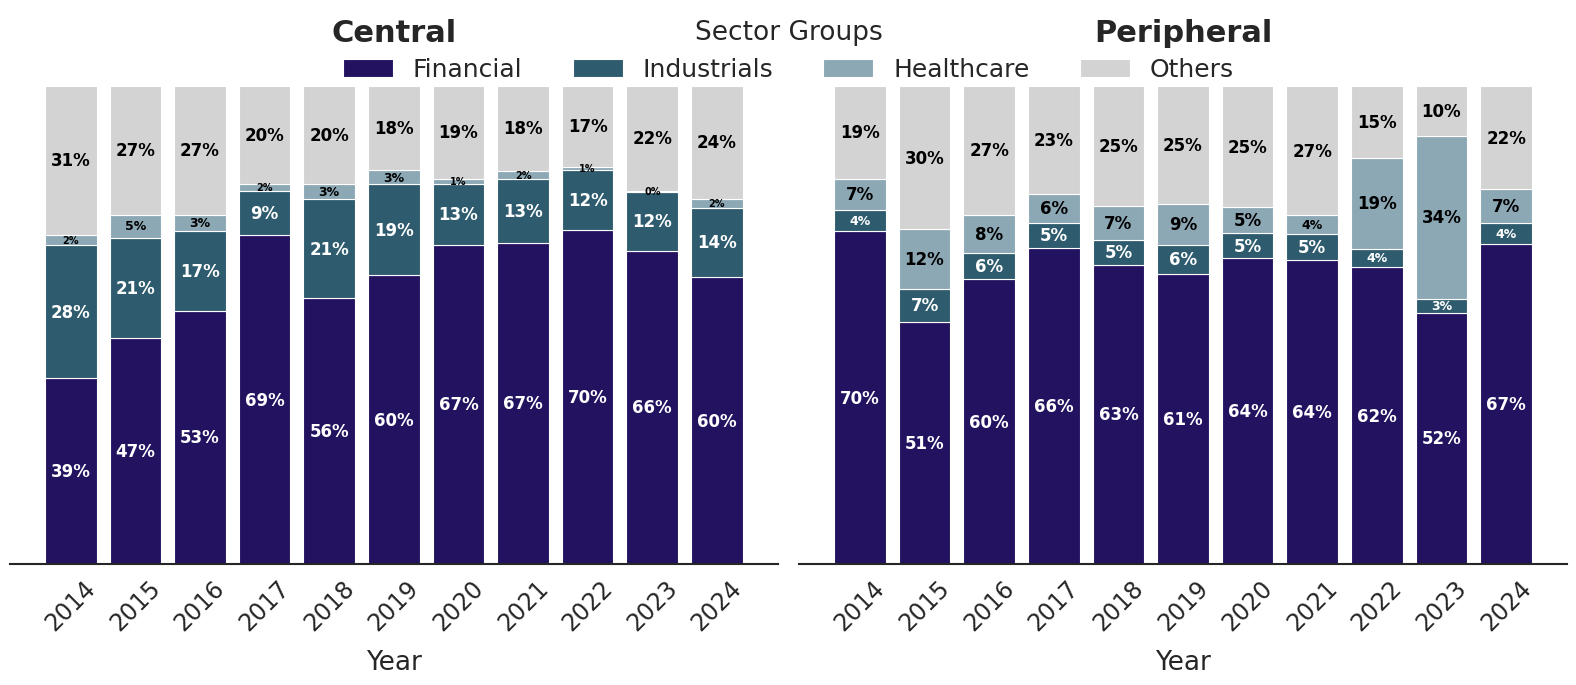


Gerando Evolução Top 3 Setores + Others (Decil 1 vs 10): POZZI



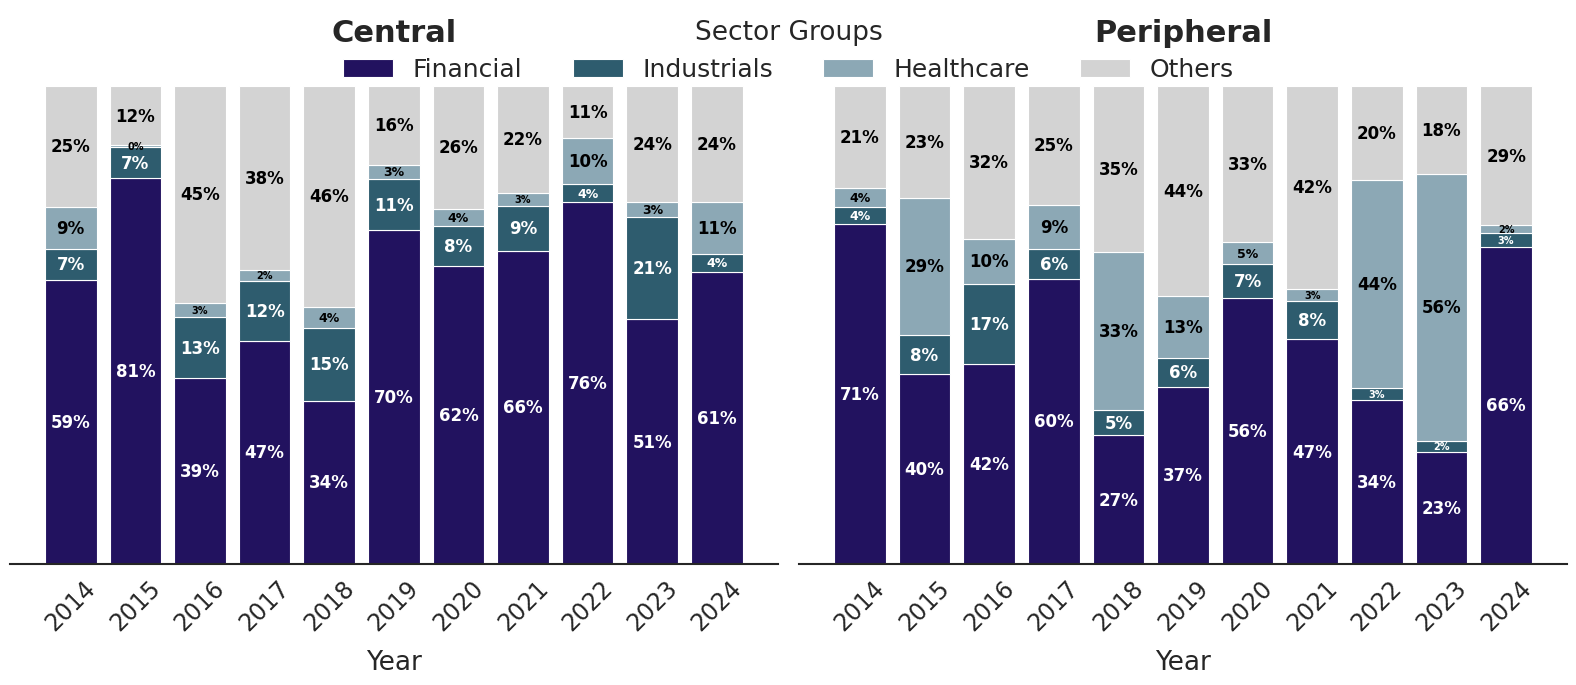

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Certifique-se de ter a final_df_metric criada
Path("../../figures").mkdir(parents=True, exist_ok=True)
sns.set_theme(style="white", context="paper", font_scale=1.5)

for metric, final_df in final_df_metric.items():
    print(f"\n{'='*50}")
    print(f"Gerando Evolução Top 3 Setores + Others (Decil 1 vs 10): {metric.upper()}")
    print(f"{'='*50}\n")
    
    # 1. Descobre os 3 maiores setores
    top_3_sectors = final_df["Sector"].value_counts().nlargest(3).index.tolist()
    
    # 2. Cria a coluna agrupada (Top 1, 2, 3 e Others)
    df_plot = final_df.copy()
    df_plot["Sector_Grouped"] = df_plot["Sector"].apply(lambda x: x if x in top_3_sectors else "Others")
    
    # Força a ordem da legenda
    sector_order = top_3_sectors + ["Others"]
    df_plot["Sector_Grouped"] = pd.Categorical(df_plot["Sector_Grouped"], categories=sector_order, ordered=True)
    
    # 3. Conta frequências por ano/decil
    counts = df_plot.groupby(["portfolio", "year", "Sector_Grouped"], observed=False).size().reset_index(name="n_firms")
    
    # 4. Prepara a Figura 1x2 (Central e Peripheral)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    axes = axes.flatten()
    
    # Expansão da paleta
    palette = ['#22125F', '#2E5C6E', '#8CA8B5', '#D3D3D3'] 
    color_dict = dict(zip(sector_order, palette))
    
    deciles = ["decil_1", "decil_10"]
    labels = ["Central", "Peripheral"]
    years = sorted(counts["year"].unique())
    x = np.arange(len(years))
    
    for i, decil in enumerate(deciles):
        ax = axes[i]
        
        # Filtra o decil e faz o pivot
        df_decil = counts[counts["portfolio"] == decil]
        piv = df_decil.pivot_table(index="year", columns="Sector_Grouped", values="n_firms", fill_value=0, observed=False)
        piv = piv.reindex(index=years, columns=sector_order, fill_value=0)
        
        # Normaliza para 100%
        piv_pct = piv.div(piv.sum(axis=1), axis=0) * 100
        piv_pct = piv_pct.fillna(0)
        
        bottom = np.zeros(len(years))
        
        # Plota as barras setor por setor
        for j, sector in enumerate(sector_order):
            values = piv_pct[sector].values
            
            bars = ax.bar(
                x, values, bottom=bottom, 
                color=color_dict[sector], 
                edgecolor="white", linewidth=0.8, 
                label=sector if i==0 else "" 
            )
            
            # ESCREVE AS PORCENTAGENS EM TODAS AS BARRAS (> 0%)
            for bar, val in zip(bars, values):
                if val > 0: # Não escreve "0%" para evitar sujeira visual
                    
                    # Se a fatia for muito fina (<5%), usa uma fonte menor para caber!
                    f_size = 12 if val >= 5 else 9 if val >= 3 else 7
                    
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{val:.0f}%",
                        ha='center', va='center', 
                        color='white' if j < 2 else 'black', 
                        fontsize=f_size, fontweight='bold'
                    )
            
            bottom += values
            
        # Estilização do Subplot
        ax.set_title(labels[i], fontsize=22, fontweight="bold", pad=15)
        
        # Formata Eixo X em ambos
        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45, fontsize=17)
        ax.set_xlabel("Year", fontsize=19, labelpad=10)
            
        # Oculta o Eixo Y
        ax.set_yticks([]) 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_linewidth(1.5)

    # Legenda Global e Título
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=4, title="Sector Groups", fontsize=18, title_fontsize=19, frameon=False)
    # fig.suptitle(f"Temporal Sector Composition — {metric.upper()}", fontsize=26, fontweight="bold", y=1.13)
    
    plt.tight_layout()
    plt.savefig(f"../../figures/sector_evolution_stacked_d1_d10_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [3]:
from IPython.display import display

out_path = Path("../../data/07_portfolios_metadata")
out_path.mkdir(parents=True, exist_ok=True)

for metric, final_df in final_df_metric.items():
    print(f"\n{'='*60}")
    print(f"Evolução Temporal dos Setores (%) - Métrica: {metric.upper()}")
    print(f"{'='*60}")
    
    for decil, label in zip(['decil_1', 'decil_10'], ['Central', 'Peripheral']):
        print(f"\n---> Portfólio: {label}")
        
        # Filtra o decil específico
        df_decil = final_df[final_df['portfolio'] == decil]
        
        # Agrupa e conta firmas por Ano/Setor
        sector_counts = df_decil.groupby(['year', 'Sector'], observed=False).size().unstack(fill_value=0)
        
        # Normaliza para porcentagem (soma da linha = 100%)
        sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100
        
        # Ordena as colunas do setor com maior peso médio histórico para o menor
        sector_order = sector_pct.mean().sort_values(ascending=False).index
        sector_pct = sector_pct[sector_order].round(2)
        
        # Mostra no Jupyter
        display(sector_pct)
        
        # Salva o arquivo CSV
        file_name = out_path / f"sector_evolution_{label.lower()}_{metric}.csv"
        sector_pct.to_csv(file_name)



Evolução Temporal dos Setores (%) - Métrica: HCM

---> Portfólio: Central


Sector,Financial,Industrials,Technology,Consumer Cyclical,Basic Materials,Real Estate,Healthcare,Communication Services,Consumer Defensive,Energy,Utilities
year,,,,,,,,,,,
2014,38.83,27.84,11.36,9.52,5.13,1.83,2.20,1.83,0.73,0.73,0.00
2015,47.24,21.03,12.41,8.62,1.38,1.03,4.83,2.41,0.69,0.34,0.00
2016,52.96,16.78,8.55,9.21,2.63,1.64,3.29,3.62,0.99,0.33,0.00
2017,68.73,9.29,7.12,5.88,2.48,1.55,1.55,0.93,0.93,1.24,0.31
2018,55.56,20.76,6.73,4.68,4.09,2.63,3.22,1.75,0.00,0.58,0.00
2019,60.44,18.96,6.04,4.95,3.02,0.27,3.02,1.92,0.82,0.55,0.00
2020,66.84,12.69,4.40,4.66,2.85,4.66,1.04,1.04,1.30,0.26,0.26
2021,67.24,13.30,4.68,5.42,2.96,2.46,1.72,0.99,0.74,0.25,0.25
2022,69.91,12.50,4.40,5.32,3.24,2.55,0.69,0.23,0.93,0.00,0.23



---> Portfólio: Peripheral


Sector,Financial,Healthcare,Technology,Industrials,Utilities,Consumer Cyclical,Real Estate,Energy,Basic Materials,Consumer Defensive,Communication Services
year,,,,,,,,,,,
2014,69.60,6.59,6.96,4.40,0.73,1.47,1.10,3.66,2.93,1.10,1.47
2015,50.69,12.41,8.28,6.90,6.21,2.76,2.76,3.45,3.79,2.07,0.69
2016,59.54,7.89,4.28,5.59,7.57,3.62,2.30,2.96,3.29,1.64,1.32
2017,66.15,5.90,4.97,5.28,7.14,4.35,1.55,0.62,1.55,0.93,1.55
2018,62.57,7.02,4.68,5.26,9.36,2.92,1.17,1.75,2.92,1.75,0.58
2019,60.71,8.52,5.22,6.04,10.44,3.02,0.55,1.92,1.37,1.65,0.55
2020,63.99,5.44,6.22,5.18,0.26,3.89,6.99,1.55,1.81,2.85,1.81
2021,63.55,3.94,4.43,5.42,0.49,8.62,5.67,2.46,0.99,1.97,2.46
2022,62.04,18.98,3.01,3.94,0.23,2.78,3.47,0.69,1.62,2.55,0.69



Evolução Temporal dos Setores (%) - Métrica: POZZI

---> Portfólio: Central


Sector,Financial,Industrials,Energy,Healthcare,Consumer Cyclical,Technology,Basic Materials,Consumer Defensive,Communication Services,Real Estate,Utilities
year,,,,,,,,,,,
2014,59.34,6.59,0.00,8.79,7.69,4.03,1.83,7.69,2.93,1.10,0.00
2015,80.69,6.55,0.00,0.34,2.07,1.72,0.34,6.55,1.72,0.00,0.00
2016,38.82,12.83,23.03,2.96,1.97,5.59,9.87,1.97,0.99,0.66,1.32
2017,46.75,12.38,14.86,2.48,1.24,4.02,12.69,2.17,1.24,0.93,1.24
2018,34.21,15.20,14.62,4.39,7.89,4.39,6.43,3.22,3.51,5.26,0.88
2019,69.78,10.71,0.82,3.02,4.12,1.10,4.67,1.92,0.82,3.02,0.00
2020,62.44,8.29,9.84,3.63,4.40,3.37,1.55,1.55,1.81,3.11,0.00
2021,65.52,9.36,8.13,2.71,2.96,3.45,2.71,2.71,1.72,0.49,0.25
2022,75.69,3.70,0.23,9.72,1.16,3.94,0.23,3.70,0.93,0.69,0.00



---> Portfólio: Peripheral


Sector,Financial,Healthcare,Technology,Consumer Cyclical,Industrials,Real Estate,Basic Materials,Energy,Consumer Defensive,Utilities,Communication Services
year,,,,,,,,,,,
2014,71.06,4.03,7.69,0.73,3.66,1.10,4.76,5.13,0.37,0.73,0.73
2015,39.66,28.62,7.24,5.17,8.28,2.07,4.14,1.72,1.38,0.34,1.38
2016,41.78,9.54,9.21,13.82,16.78,2.63,1.32,0.00,1.32,1.97,1.64
2017,59.63,9.32,5.28,6.21,6.21,1.24,0.93,0.93,0.93,8.39,0.93
2018,26.90,33.04,24.56,2.63,5.26,2.05,2.34,0.29,1.75,0.29,0.88
2019,37.09,12.91,6.32,23.08,6.04,1.65,3.30,1.92,5.77,0.27,1.65
2020,55.70,4.66,4.66,7.51,6.99,12.18,1.81,1.81,2.85,0.26,1.55
2021,47.04,2.71,5.91,14.29,7.88,10.34,1.23,2.46,3.20,0.74,4.19
2022,34.26,43.52,3.47,5.79,2.55,5.09,1.62,0.00,2.78,0.23,0.69


## Boxplots

Gerando Painel de Métricas para HCM...


/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

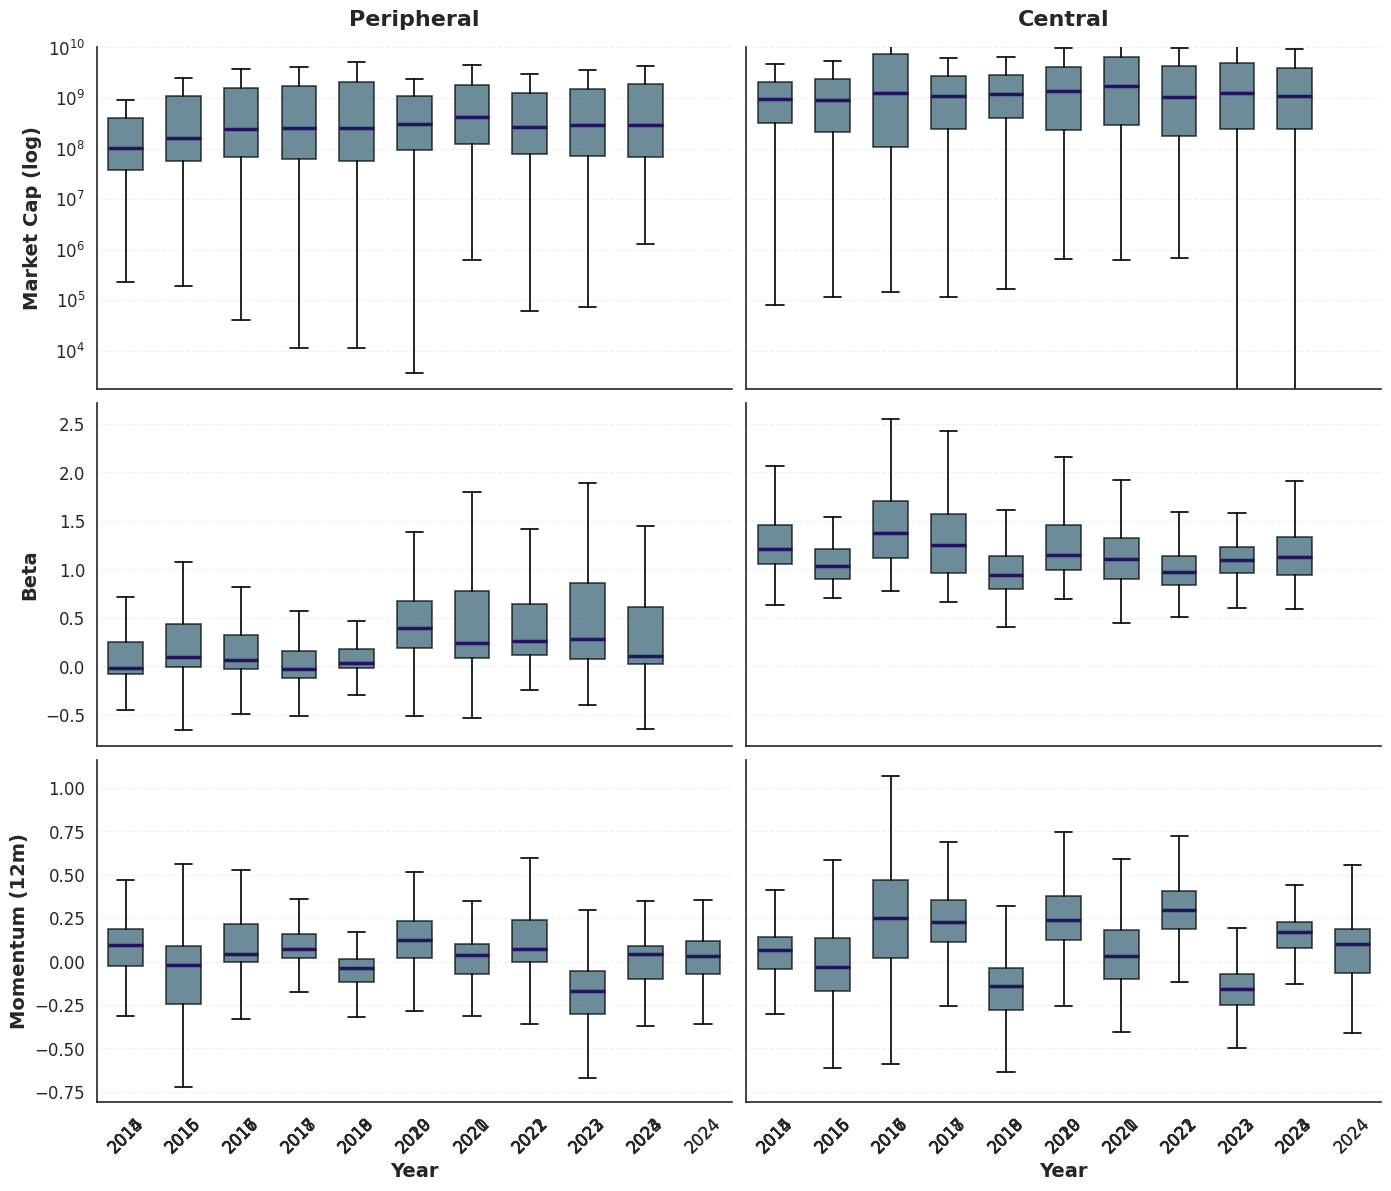

Gerando Painel de Métricas para POZZI...


/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_13840/820378353.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

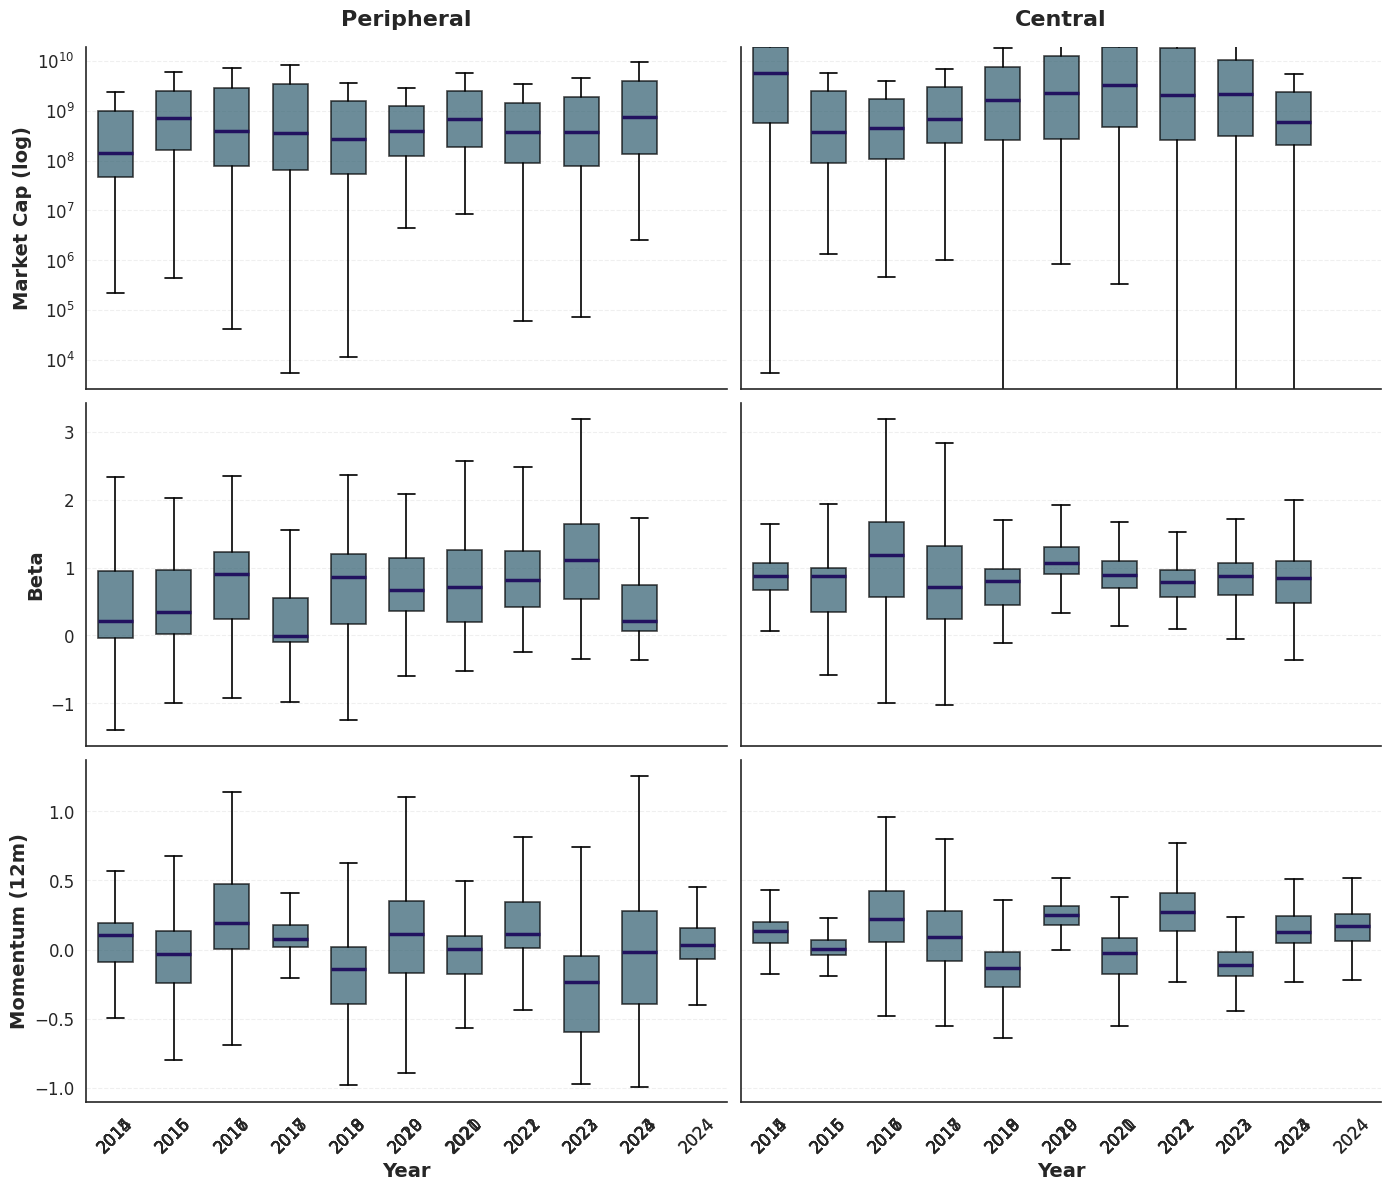

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_combined_metrics_evolution(
    df,
    network_metric_name,
    portfolios=None,
    figsize=(14, 12),
    showfliers=False,
    save=False,
    out_dir="../../figures",
    dpi=300
):
    """
    Gera um painel 3x2 com a evolução de Market Cap, Beta e Momentum
    """
    # plt.style.use('seaborn-v0_8-whitegrid')
    # sns.set_context("paper", font_scale=1.3)

    sns.set_theme(style="white", context="paper")
    
    if portfolios is None:
        portfolios = ['decil_10', 'decil_1']
        
    portfolio_titles = {
        'decil_10': 'Peripheral',
        'decil_1': 'Central'
    }
    
    # Configuração das 3 métricas
    metrics_info = [
        {'prefix': 'mcap',     'label': 'Market Cap (log)', 'log': True},
        {'prefix': 'beta',     'label': 'Beta',             'log': False},
        {'prefix': 'momentum', 'label': 'Momentum (12m)',   'log': False}
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=True)
    
    box_color = '#2E5C6E'
    median_color = "#22125F"
    TITLE_SIZE = 16
    LABEL_SIZE = 14
    TICK_SIZE = 12
    
    for row_idx, m_info in enumerate(metrics_info):
        prefix = m_info['prefix']
        log_scale = m_info['log']
        y_label = m_info['label']
        
        # 1. Filtra e derrete (melt) os dados da métrica atual
        metric_cols = df.columns[df.columns.str.match(fr"^{prefix}_\d{{4}}$")].tolist()
        if not metric_cols:
            continue
            
        metric_long = df.melt(
            id_vars=["Ticker", "portfolio"], value_vars=metric_cols,
            var_name="metric_year", value_name="value"
        )
        metric_long["year"] = metric_long["metric_year"].str.replace(f"{prefix}_", "", regex=False).astype(int)
        metric_long = metric_long.dropna(subset=["value"])
        
        # 2. Plota os dois decis (colunas)
        for col_idx, portfolio in enumerate(portfolios):
            ax = axes[row_idx, col_idx]
            
            data_p = metric_long[metric_long["portfolio"] == portfolio]
            years = sorted(data_p["year"].unique())
            boxplot_data = [data_p[data_p["year"] == y]["value"].values for y in years]
            
            ax.boxplot(
                boxplot_data, labels=years, patch_artist=True, showfliers=showfliers, widths=0.6,
                medianprops=dict(color=median_color, linewidth=2.5),
                boxprops=dict(facecolor=box_color, edgecolor='black', linewidth=1.2, alpha=0.7),
                whiskerprops=dict(color='black', linewidth=1.2),
                capprops=dict(color='black', linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
            )
            
            if log_scale:
                ax.set_yscale("log")
                
            # Estilização
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.2)
            ax.spines['bottom'].set_linewidth(1.2)
            ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
            ax.set_axisbelow(True)
            ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, width=1.2)
            
            # Textos e Eixos
            if row_idx == 2: # Na última linha, coloca os anos
                ax.tick_params(axis='x', rotation=45)
                ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
                
            if col_idx == 0: # Na primeira coluna, coloca o nome da métrica
                ax.set_ylabel(y_label, fontsize=LABEL_SIZE, fontweight="bold")
                
            if row_idx == 0: # Na primeira linha, coloca o título do Decil
                p_title = portfolio_titles.get(portfolio, portfolio.capitalize())
                ax.set_title(p_title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
                
        # Sincroniza o eixo Y entre o Central e Peripheral para a métrica atual
        axes[row_idx, 1].sharey(axes[row_idx, 0])
        plt.setp(axes[row_idx, 1].get_yticklabels(), visible=False)

    # fig.suptitle(f"Financial Metrics Evolution - {network_metric_name.upper()}", 
    #              fontsize=22, fontweight="bold", y=1.02)
    plt.tight_layout()
    
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        filename = f"combined_metrics_evolution_{network_metric_name}.png"
        fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight", facecolor='white', edgecolor='none')

    plt.show()

# --- Chamada do Loop ---
for metric, df in final_df_metric.items():
    print(f"Gerando Painel de Métricas para {metric.upper()}...")
    plot_combined_metrics_evolution(
        df=df,
        network_metric_name=metric,
        save=True,
        out_dir="../../figures"  # Vai salvar como combined_metrics_evolution_hrm.png e _pozzi.png
    )

## Composition

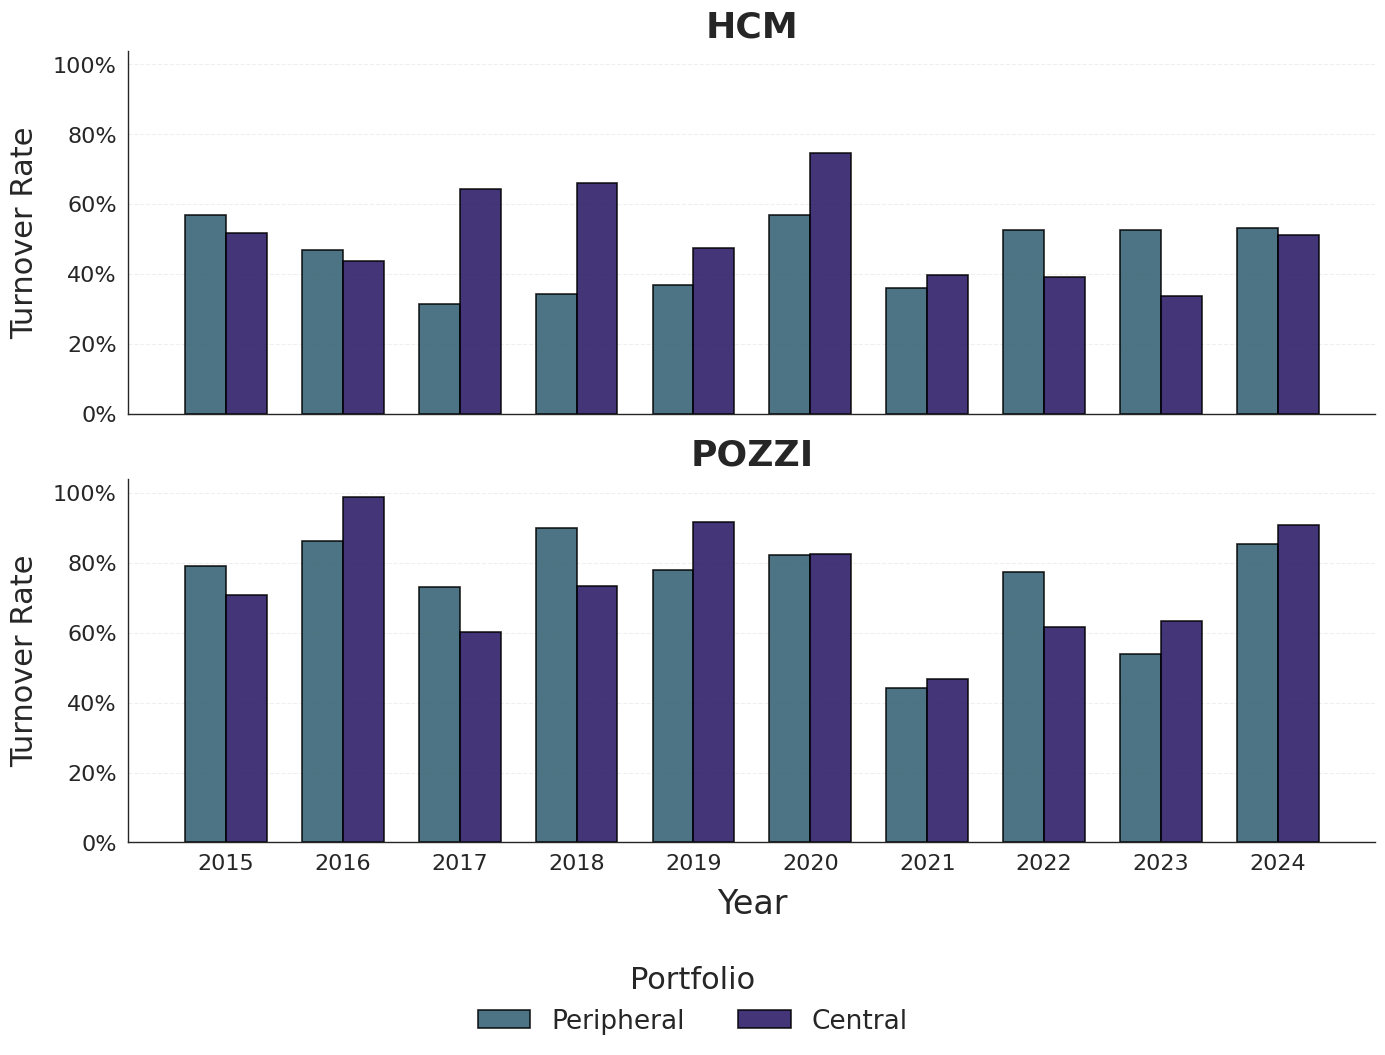

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# =========================================================================
# 1. RECRIANDO O TURNOVER_DF_METRIC A PARTIR DA FINAL_DF_METRIC
# =========================================================================
turnover_df_metric = {}

for metric, df in final_df_metric.items():
    records = []
    
    for portfolio in ['decil_1', 'decil_10']:
        port_df = df[df['portfolio'] == portfolio]
        years = sorted(port_df['year'].unique())
        
        prev_tickers = set()
        
        for i, year in enumerate(years):
            current_tickers = set(port_df[port_df['year'] == year]['Ticker'])
            
            if i == 0:
                turnover_rate = 0.0
            else:
                additions = len(current_tickers - prev_tickers)
                deletions = len(prev_tickers - current_tickers)
                avg_size = (len(current_tickers) + len(prev_tickers)) / 2
                
                # Fórmula clássica de One-Sided Turnover (Composição)
                if avg_size == 0:
                    turnover_rate = 0.0
                else:
                    turnover_rate = ((additions + deletions) / 2) / avg_size
                    
            records.append({'portfolio': portfolio, 'year': year, 'turnover_rate': turnover_rate})
            prev_tickers = current_tickers

    turnover_df_metric[metric] = pd.DataFrame(records)

# =========================================================================
# 2. PLOT DO GRÁFICO (2x1)
# =========================================================================
sns.set_theme(style="white", context="paper", font_scale=1.2)
palette = ['#2E5C6E', '#22125F'] 

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)
metrics = ["hcm", "pozzi"]

for ax, metric in zip(axes, metrics):
    turnover_df = turnover_df_metric[metric]
    
    # Filtra 2014 pois é o ano base e tem turnover 0%
    turnover_df = turnover_df[turnover_df['year'] != '2014']
    
    width = 0.35
    years = sorted(turnover_df["year"].unique())
    x = range(len(years))
    offsets = [-width / 2, width / 2]

    portfolios_to_plot = ["decil_10", "decil_1"]
    labels_to_plot = ["Peripheral", "Central"]

    for i, (portfolio_code, label) in enumerate(zip(portfolios_to_plot, labels_to_plot)):
        group = turnover_df[turnover_df["portfolio"] == portfolio_code].sort_values("year")
        ax.bar(
            [xi + offsets[i] for xi in x], group["turnover_rate"],
            width=width, 
            color=palette[i], 
            alpha=0.85,
            label=label,
            edgecolor='black', 
            linewidth=1.2
        )

    ax.set_xticks(x)
    
    if ax == axes[-1]:
        ax.set_xticklabels(years, rotation=0, fontsize=19)
        ax.set_xlabel("Year", fontsize=24, labelpad=10)
        
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
    ax.set_title(f"{metric.upper()}", fontsize=26, fontweight="bold", pad=10)
    ax.tick_params(axis="both", labelsize=16)
    
    ax.set_ylabel("Turnover Rate", fontsize=22, labelpad=10)
    
    ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=2, title="Portfolio", title_fontsize=22, fontsize=19, frameon=False)

sns.despine(fig=fig)
plt.tight_layout()

plt.subplots_adjust(bottom=0.15) 

Path("../../figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../../figures/turnover_evolution_hcm_pozzi.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
print("Gerando Tabelas de Turnover...")

for metric in ["hcm", "pozzi"]:
    print(f"\n{'='*50}")
    print(f"Tabela de Turnover Rate (%) - Métrica: {metric.upper()}")
    print(f"{'='*50}")
    
    # Extrai o dataframe criado pelo seu código anterior
    turnover_df = turnover_df_metric[metric].copy()
    
    # Remove 2014 pois é o ano base de transição (Turnover 0%)
    turnover_df = turnover_df[turnover_df['year'] != '2014']
    
    # Pivot Table para colocar Anos nas Linhas e Decis nas Colunas
    turnover_pivot = turnover_df.pivot_table(
        index='year', 
        columns='portfolio', 
        values='turnover_rate'
    )
    
    # Renomeia colunas para o Paper e transforma em formato de Porcentagem (%)
    turnover_pivot = turnover_pivot.rename(columns={
        'decil_1': 'Central (D1)', 
        'decil_10': 'Peripheral (D10)'
    })
    
    turnover_pivot_pct = (turnover_pivot * 100).round(2)
    
    # Exibe no Jupyter
    display(turnover_pivot_pct)
    
    # Salva o arquivo CSV
    turnover_pivot_pct.to_csv(out_path / f"turnover_rate_table_{metric}.csv")


Gerando Tabelas de Turnover...

Tabela de Turnover Rate (%) - Métrica: HCM


portfolio,Central (D1),Peripheral (D10)
year,,
2015,51.69,57.02
2016,43.77,46.80
2017,64.27,31.31
2018,66.02,34.34
2019,47.31,36.83
2020,74.67,56.80
2021,39.65,35.86
2022,39.14,52.74
2023,33.71,52.52



Tabela de Turnover Rate (%) - Métrica: POZZI


portfolio,Central (D1),Peripheral (D10)
year,,
2015,70.87,79.04
2016,98.99,86.20
2017,60.13,73.16
2018,73.53,90.06
2019,91.78,77.90
2020,82.67,82.40
2021,46.72,44.19
2022,61.81,77.33
2023,63.49,53.86
